In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1. Cargar los datos
df = pd.read_csv("audio_features_15s.csv")

# Ingeniería de variables: Relación de Brillo (evita división por cero)
df['brightness_ratio'] = df['rolloff'] / (df['spectral_centroid'] + 1e-6)


In [ ]:
# 2. Separar Features (X), Target (y) y Grupos (song_id)
X = df.drop(columns=['label', 'song_id', 'segment_type'])
y = df['label']
groups = df['song_id']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# 3. GroupShuffleSplit — mismo random_state que v1 para comparación justa
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=9347234)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

In [ ]:
# 4. Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 1er Run de Modelos

In [ ]:
# 5. Definir modelos
# ─── Modelos originales ───────────────────────────────────────────────────────
svm_rbf  = SVC(kernel='rbf',    probability=True, random_state=42)
rf       = RandomForestClassifier(n_estimators=100, random_state=42)
gb       = GradientBoostingClassifier(n_estimators=100, random_state=42)

# ─── Nuevos kernels SVM ───────────────────────────────────────────────────────
# Linear: separa con una línea recta, más rápido, mejor en espacios de alta dimensión
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

# Poly: captura interacciones entre features (ej. tempo × chroma)
# degree=3 es el estándar, C=1 regularización por defecto
svm_poly   = SVC(kernel='poly', degree=3, probability=True, random_state=42)

# LinearSVC: versión optimizada del kernel lineal, mucho más rápida en datasets grandes
# Necesita CalibratedClassifierCV para obtener probabilidades
linear_svc = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))

# ─── Voting Classifier (combinación de los mejores) ──────────────────────────
# Combina SVM-Linear + GB + RF: vota por mayoría suave (soft = usa probabilidades)
voting = VotingClassifier(
    estimators=[
        ('svm_linear', SVC(kernel='linear', probability=True, random_state=42)),
        ('gb',         GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('rf',         RandomForestClassifier(n_estimators=100, random_state=42))
    ],
    voting='soft'
)

models = {
    # Originales
    "SVM (RBF)": svm_rbf,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    # Nuevos
    "SVM (Linear)": svm_linear,
    "SVM (Poly)": svm_poly,
    "LinearSVC": linear_svc,
    "Voting (Linear + GB + RF)": voting
}


  Entrenando: SVM (RBF)
Exactitud (Accuracy) Global: 0.7103

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.58      0.66      0.62       155
     Hip-Hop       0.68      0.64      0.66        98
        Rock       0.55      0.64      0.59        86
   Vallenato       0.88      0.77      0.82       129
     clasicc       0.94      0.96      0.95       149
        jazz       0.85      0.85      0.85       177
         pop       0.47      0.42      0.44       169

    accuracy                           0.71       963
   macro avg       0.71      0.71      0.70       963
weighted avg       0.71      0.71      0.71       963



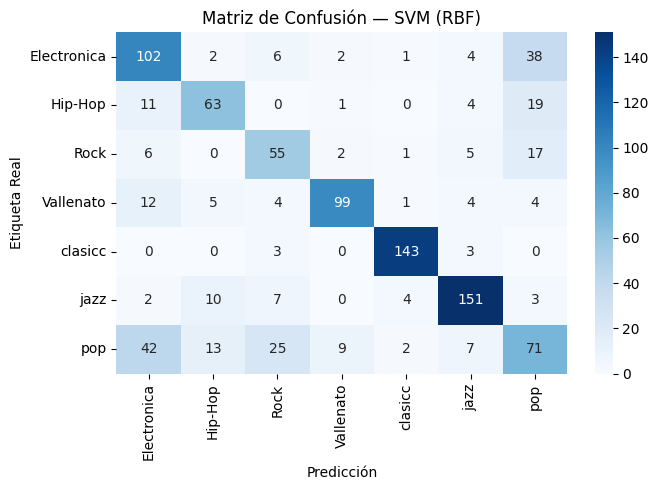


  Entrenando: Random Forest
Exactitud (Accuracy) Global: 0.7103

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.65      0.72      0.68       155
     Hip-Hop       0.59      0.62      0.61        98
        Rock       0.61      0.83      0.70        86
   Vallenato       0.84      0.78      0.81       129
     clasicc       0.97      0.96      0.97       149
        jazz       0.75      0.80      0.78       177
         pop       0.47      0.33      0.38       169

    accuracy                           0.71       963
   macro avg       0.70      0.72      0.70       963
weighted avg       0.70      0.71      0.70       963



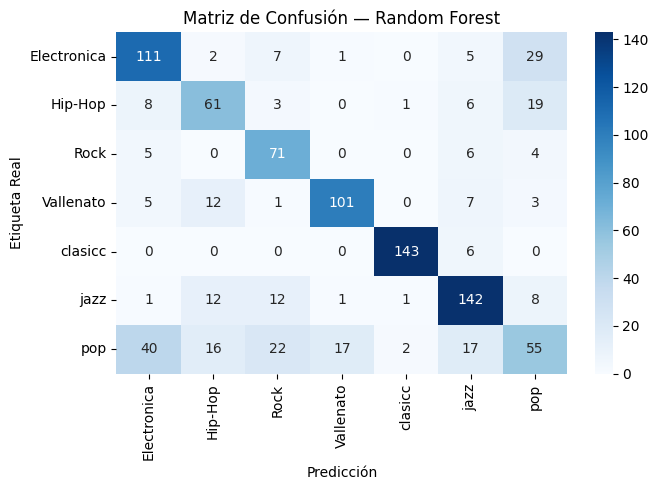


  Entrenando: Gradient Boosting
Exactitud (Accuracy) Global: 0.6989

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.69      0.64      0.66       155
     Hip-Hop       0.65      0.63      0.64        98
        Rock       0.61      0.80      0.69        86
   Vallenato       0.83      0.74      0.78       129
     clasicc       0.97      0.93      0.95       149
        jazz       0.79      0.74      0.76       177
         pop       0.42      0.46      0.44       169

    accuracy                           0.70       963
   macro avg       0.71      0.71      0.70       963
weighted avg       0.71      0.70      0.70       963



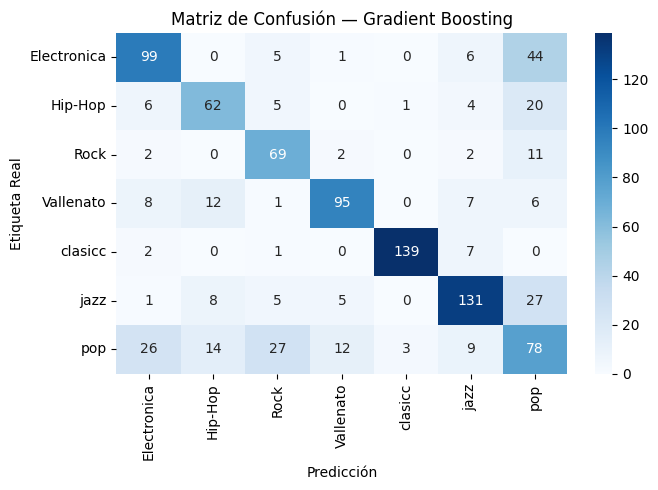


  Entrenando: SVM (Linear)
Exactitud (Accuracy) Global: 0.6750

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.51      0.50      0.50       155
     Hip-Hop       0.56      0.63      0.59        98
        Rock       0.50      0.62      0.55        86
   Vallenato       0.86      0.79      0.83       129
     clasicc       0.94      0.86      0.90       149
        jazz       0.82      0.79      0.80       177
         pop       0.52      0.52      0.52       169

    accuracy                           0.67       963
   macro avg       0.67      0.67      0.67       963
weighted avg       0.69      0.67      0.68       963



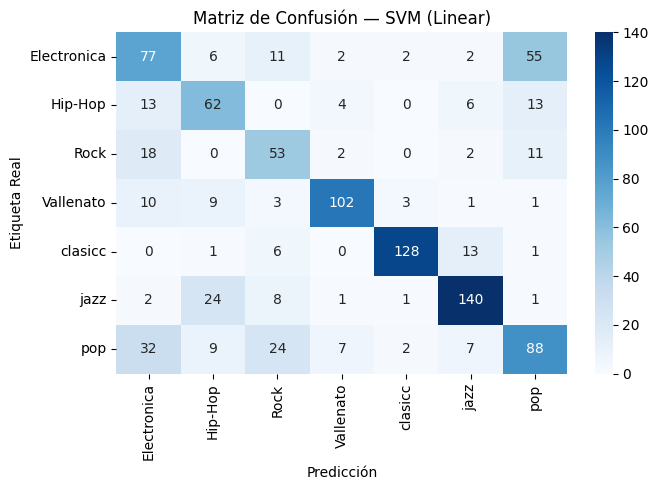


  Entrenando: SVM (Poly)
Exactitud (Accuracy) Global: 0.6324

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.65      0.48      0.55       155
     Hip-Hop       0.70      0.62      0.66        98
        Rock       0.35      0.83      0.49        86
   Vallenato       0.52      0.88      0.65       129
     clasicc       0.98      0.87      0.92       149
        jazz       0.85      0.68      0.76       177
         pop       0.61      0.22      0.33       169

    accuracy                           0.63       963
   macro avg       0.67      0.66      0.62       963
weighted avg       0.69      0.63      0.63       963



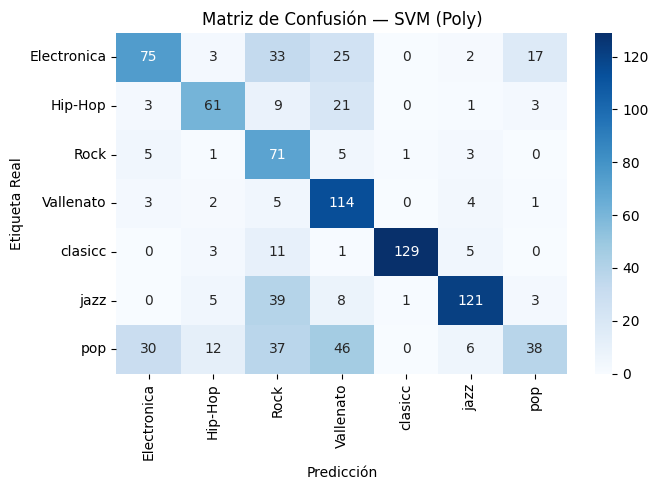


  Entrenando: LinearSVC
Exactitud (Accuracy) Global: 0.6771

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.58      0.51      0.54       155
     Hip-Hop       0.55      0.57      0.56        98
        Rock       0.51      0.72      0.60        86
   Vallenato       0.76      0.70      0.73       129
     clasicc       0.92      0.91      0.92       149
        jazz       0.79      0.84      0.81       177
         pop       0.54      0.49      0.51       169

    accuracy                           0.68       963
   macro avg       0.67      0.68      0.67       963
weighted avg       0.68      0.68      0.68       963



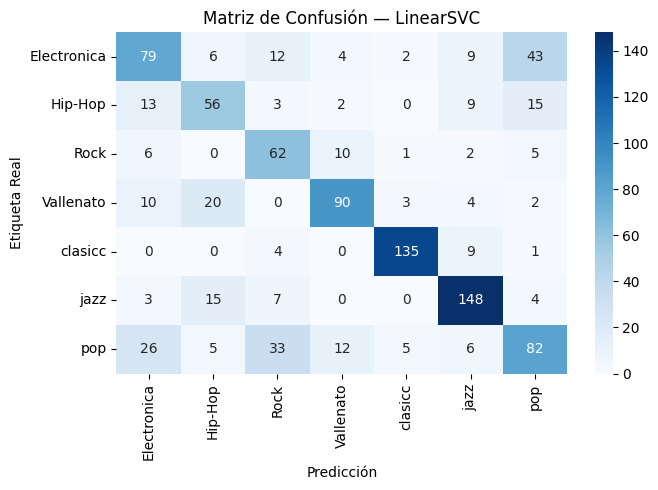


  Entrenando: Voting (Linear + GB + RF)
Exactitud (Accuracy) Global: 0.7383

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.65      0.64      0.64       155
     Hip-Hop       0.69      0.69      0.69        98
        Rock       0.68      0.81      0.74        86
   Vallenato       0.88      0.80      0.84       129
     clasicc       0.97      0.93      0.95       149
        jazz       0.80      0.83      0.82       177
         pop       0.51      0.50      0.51       169

    accuracy                           0.74       963
   macro avg       0.74      0.74      0.74       963
weighted avg       0.74      0.74      0.74       963



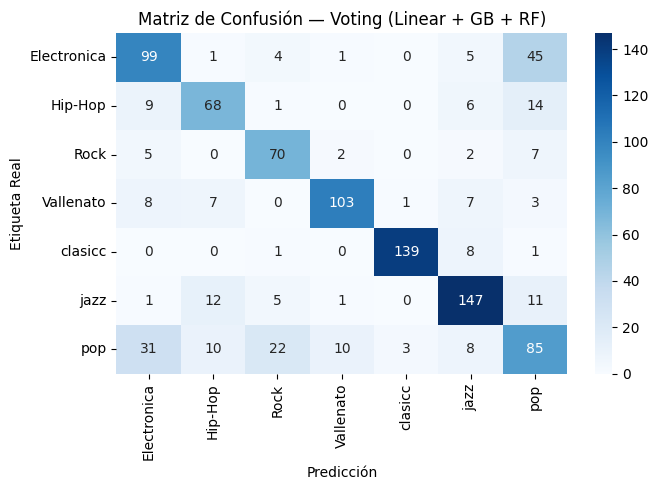

In [ ]:
# 6. Entrenamiento, evaluación y comparación
resultados = []  # Para tabla comparativa al final

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Entrenando: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"Exactitud (Accuracy) Global: {acc:.4f}\n")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Guardar para tabla final
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    resultados.append({'Modelo': name, 'Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión — {name}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

In [ ]:
# 7. Tabla comparativa final de todos los modelos
df_resultados = pd.DataFrame(resultados).sort_values('Macro F1', ascending=False)
df_resultados = df_resultados.reset_index(drop=True)
df_resultados.index += 1  # Ranking desde 1

print("\n" + "="*50)
print("       RANKING FINAL DE MODELOS")
print("="*50)
print(df_resultados.to_string())
print("="*50)
print("\nMejor modelo por Macro F1:", df_resultados.iloc[0]['Modelo'])


       RANKING FINAL DE MODELOS
                      Modelo  Accuracy  Macro F1
1  Voting (Linear + GB + RF)    0.7383    0.7416
2                  SVM (RBF)    0.7103    0.7044
3              Random Forest    0.7103    0.7042
4          Gradient Boosting    0.6989    0.7041
5               SVM (Linear)    0.6750    0.6711
6                  LinearSVC    0.6771    0.6669
7                 SVM (Poly)    0.6324    0.6233

Mejor modelo por Macro F1: Voting (Linear + GB + RF)


# 2do Run de Modelos

Se ve que el mejor modelo es el ensemble "voting":

1. En el Rock & Pop es donde el modelo esta realmente sufriendo ya que el Rock tiene muy baja precision en 0.37 y muy alto el recall 0.9 lo que nos da a entender que muy probablemente el modelo lo que está haciendo es que lo que no entiende como una clase muy claramente lo manda a rock haciendo que meta rock donde va pero tambien cuando no es y en el Pop sucede que ni la presicion, ni el f1 ni el recall son buenos lo cual puede que suceda porque el pop es un genero que comparte caracteristicas con los demas al tiempo

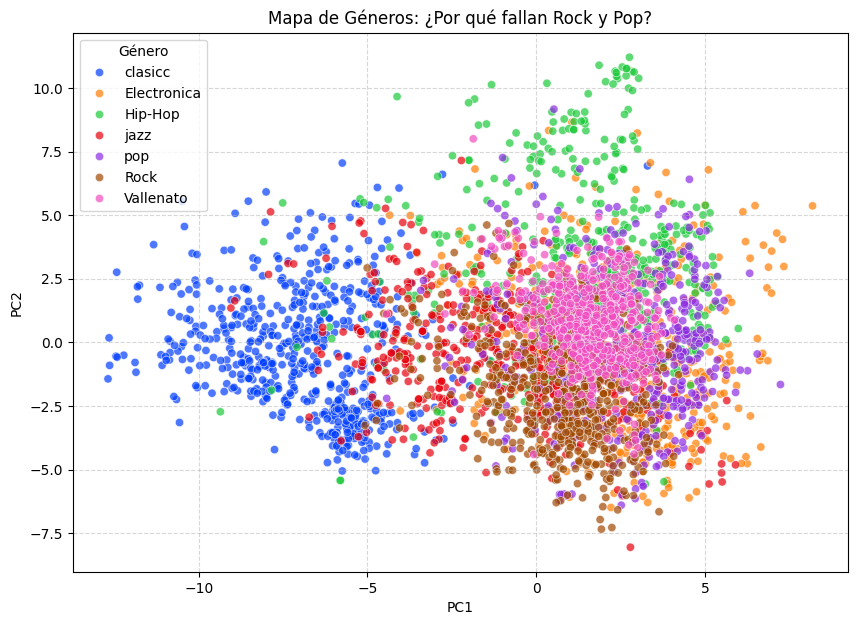

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reducimos a 2 dimensiones para poder graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Creamos un DataFrame para graficar con Seaborn
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Género'] = le.inverse_transform(y_train)

# 3. Graficamos
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Género', alpha=0.7, palette='bright')
plt.title('Mapa de Géneros: ¿Por qué fallan Rock y Pop?')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

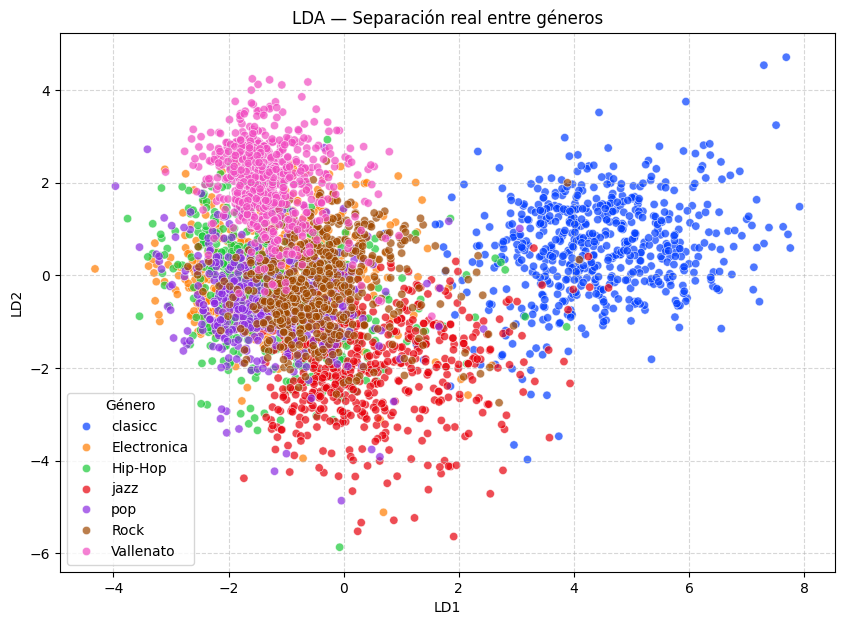

In [ ]:
# OPCIÓN A — LDA: la mejor para ver separación real entre clases
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, y_train)  # usa las etiquetas ← clave

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['Género'] = le.inverse_transform(y_train)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_lda, x='LD1', y='LD2', hue='Género', alpha=0.7, palette='bright')
plt.title('LDA — Separación real entre géneros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Vemos que Pop & Rock comparten un gran campo de las caracteristicas por lo que muy probablemente lo que esta sucediendo es que no se diferencian del todo bien,necesitamos o otras caracteristicas o mas datos o algo mas que nos haga realmente diferenciar estos 2 de los demas y entre si. **El punto es mejorar la frontera de decision**

In [ ]:
df['label'].value_counts()

,count
label,
clasicc,746
Vallenato,729
jazz,706
Electronica,705
Rock,679
pop,670
Hip-Hop,550


Para eso nos podría servir el **SMOTE (Synthetic Minority Over-sampling Technique)** o

## **SMOTE**

Aunque el Rock y el Pop tengan casi 150 muestras, sus "puntos" en el espacio matemático pueden estar muy dispersos o rodeados de mucho "ruido" de otros géneros.

1. SMOTE no se usa solo para cuando hay "poquitos" datos, sino para densificar las zonas donde el modelo duda. Al crear puntos intermedios entre los datos reales de Rock, estamos rellenando los huecos vacíos en el mapa.

2. Al haber más puntos de Rock y Pop concentrados en sus áreas, los algoritmos como el SVM o el Voting Classifier pueden trazar una "línea de frontera" mucho más precisa y menos zigzagueante.

3. Ayuda a que el modelo no se aprenda de memoria una canción de Rock específica (Overfitting), sino que entienda la "región" donde suele vivir el sonido del Rock.


Antes de SMOTE: Counter({np.int64(3): 600, np.int64(4): 597, np.int64(2): 593, np.int64(0): 550, np.int64(5): 529, np.int64(6): 501, np.int64(1): 452})
Después de SMOTE: Counter({np.int64(4): 600, np.int64(0): 600, np.int64(1): 600, np.int64(5): 600, np.int64(6): 600, np.int64(2): 600, np.int64(3): 600})

  Entrenando con SMOTE: SVM (RBF)
Exactitud (Accuracy): 0.7186
Macro F1-Score: 0.7128

              precision    recall  f1-score   support

 Electronica       0.60      0.66      0.63       155
     Hip-Hop       0.68      0.64      0.66        98
        Rock       0.57      0.64      0.60        86
   Vallenato       0.88      0.77      0.82       129
     clasicc       0.94      0.96      0.95       149
        jazz       0.85      0.86      0.85       177
         pop       0.48      0.46      0.47       169

    accuracy                           0.72       963
   macro avg       0.72      0.71      0.71       963
weighted avg       0.72      0.72      0.72       963



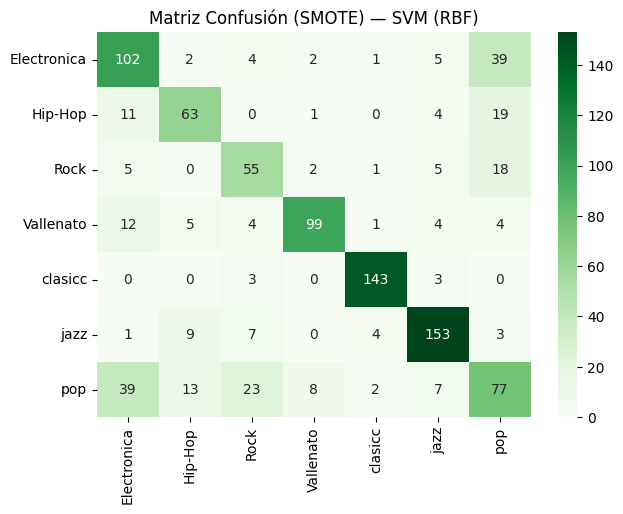


  Entrenando con SMOTE: Random Forest
Exactitud (Accuracy): 0.6926
Macro F1-Score: 0.6857

              precision    recall  f1-score   support

 Electronica       0.68      0.70      0.69       155
     Hip-Hop       0.54      0.63      0.58        98
        Rock       0.60      0.72      0.66        86
   Vallenato       0.79      0.68      0.73       129
     clasicc       0.97      0.95      0.96       149
        jazz       0.75      0.81      0.78       177
         pop       0.45      0.36      0.40       169

    accuracy                           0.69       963
   macro avg       0.68      0.69      0.69       963
weighted avg       0.69      0.69      0.69       963



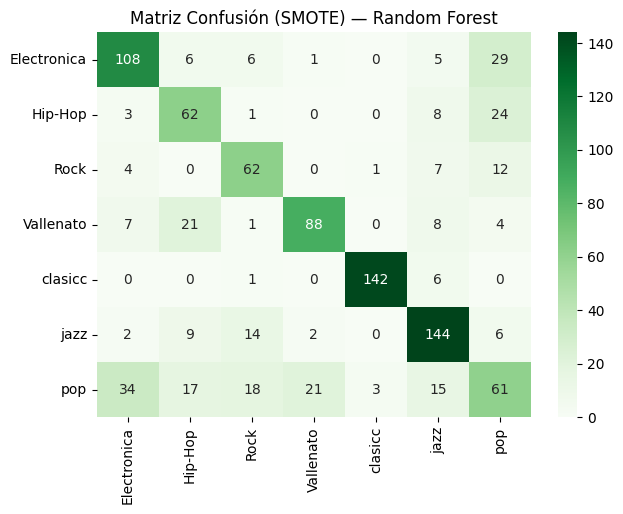


  Entrenando con SMOTE: Gradient Boosting
Exactitud (Accuracy): 0.6916
Macro F1-Score: 0.6938

              precision    recall  f1-score   support

 Electronica       0.66      0.60      0.63       155
     Hip-Hop       0.61      0.64      0.62        98
        Rock       0.61      0.76      0.67        86
   Vallenato       0.81      0.71      0.76       129
     clasicc       0.97      0.94      0.96       149
        jazz       0.78      0.78      0.78       177
         pop       0.42      0.44      0.43       169

    accuracy                           0.69       963
   macro avg       0.70      0.70      0.69       963
weighted avg       0.70      0.69      0.69       963



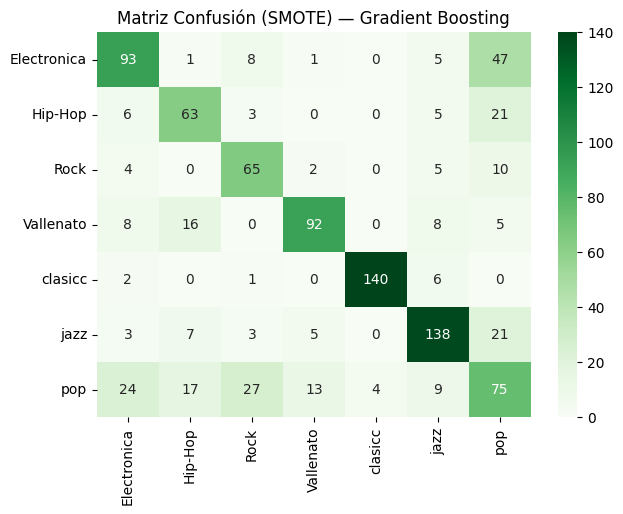


  Entrenando con SMOTE: SVM (Linear)
Exactitud (Accuracy): 0.6656
Macro F1-Score: 0.6633

              precision    recall  f1-score   support

 Electronica       0.49      0.47      0.48       155
     Hip-Hop       0.54      0.64      0.59        98
        Rock       0.51      0.60      0.55        86
   Vallenato       0.88      0.78      0.82       129
     clasicc       0.95      0.86      0.90       149
        jazz       0.82      0.80      0.81       177
         pop       0.48      0.50      0.49       169

    accuracy                           0.67       963
   macro avg       0.67      0.66      0.66       963
weighted avg       0.68      0.67      0.67       963



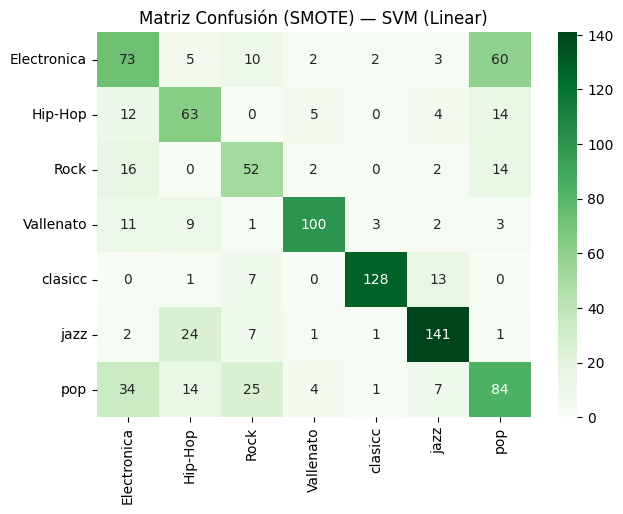


  Entrenando con SMOTE: Voting (Linear + GB + RF)
Exactitud (Accuracy): 0.7279
Macro F1-Score: 0.7305

              precision    recall  f1-score   support

 Electronica       0.66      0.65      0.65       155
     Hip-Hop       0.67      0.67      0.67        98
        Rock       0.68      0.76      0.71        86
   Vallenato       0.87      0.78      0.82       129
     clasicc       0.98      0.93      0.95       149
        jazz       0.80      0.84      0.82       177
         pop       0.48      0.50      0.49       169

    accuracy                           0.73       963
   macro avg       0.73      0.73      0.73       963
weighted avg       0.73      0.73      0.73       963



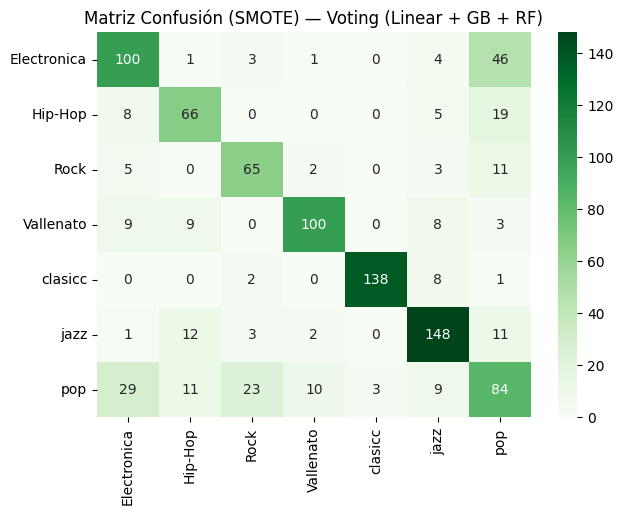

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df.drop(columns=['label', 'song_id', 'segment_type'])
y = df['label']
groups = df['song_id']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# GroupShuffleSplit (Mantenemos el random_state para que el TEST sea el mismo de antes)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=9347234)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── NUEVO PASO: APLICACIÓN DE SMOTE ─────────────────────────────────────────
# Explicación para clase: Balanceamos el Hip-Hop y densificamos Rock/Pop
print(f"Antes de SMOTE: {Counter(y_train)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Después de SMOTE: {Counter(y_train_res)}")
# ─────────────────────────────────────────────────────────────────────────────

# Definir modelos (Incluyendo los pesos balanceados para mayor robustez)
models = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42),
    "Voting (Linear + GB + RF)": VotingClassifier(
        estimators=[
            ('svm_linear', SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)),
            ('gb',         GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('rf',         RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ],
        voting='soft'
    )
}

# Entrenamiento, evaluación y comparación
resultados_smote = []

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Entrenando con SMOTE: {name}")
    print(f"{'='*55}")

    # IMPORTANTE: Entrenamos con los datos aumentados (res), evaluamos con test REAL
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    resultados_smote.append({'Modelo': name, 'Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Color verde para diferenciarlo
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz Confusión (SMOTE) — {name}')
    plt.show()

Realmente no mejoró mucho asi que veamos cuales son las features que realmente mas estan importando

## FE

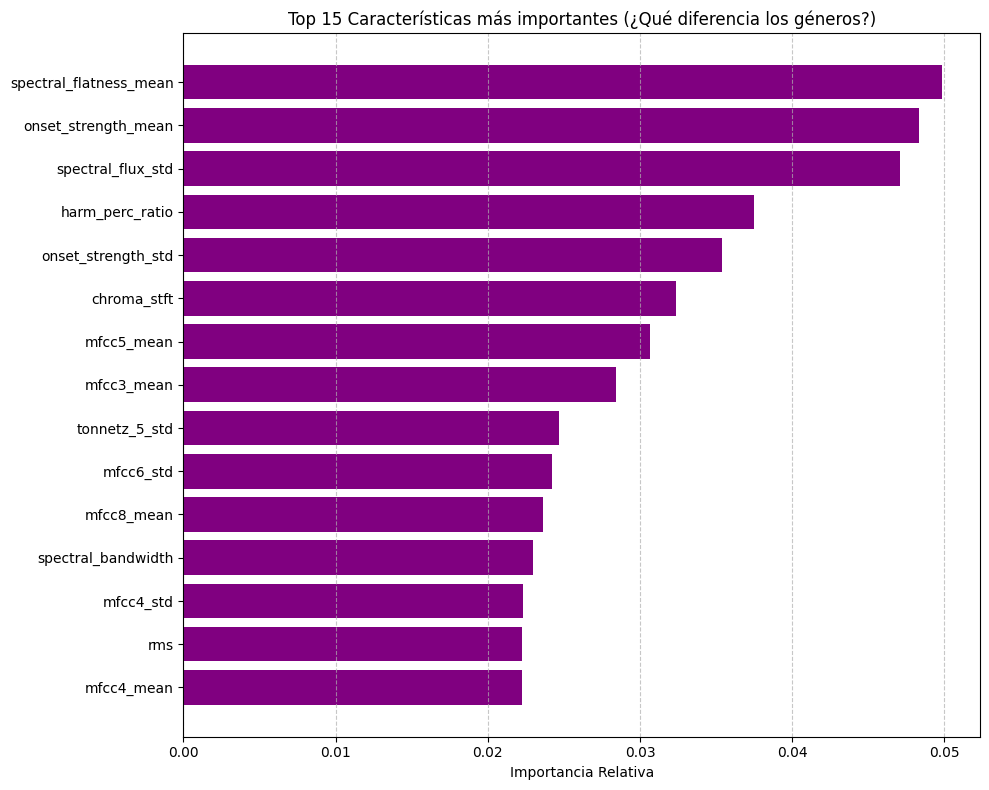

In [ ]:
# 1. Entrenamos el Random Forest con los datos de SMOTE
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_res, y_train_res)

# 2. Obtenemos la importancia y la organizamos
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]  # Tomamos las 15 más importantes

# 3. Graficamos
plt.figure(figsize=(10, 8))
plt.title('Top 15 Características más importantes (¿Qué diferencia los géneros?)')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['tempo', 'spectral_centroid', 'spectral_bandwidth', 'rolloff',
       'zero_crossing_rate', 'rms', 'chroma_stft', 'onset_strength_mean',
       'onset_strength_std', 'pitch_variance', 'spectral_flux_std',
       'mfcc1_mean', 'mfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'mfcc3_mean',
       'mfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'mfcc5_mean', 'mfcc5_std',
       'mfcc6_mean', 'mfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'mfcc8_mean',
       'mfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'mfcc10_mean', 'mfcc10_std',
       'mfcc11_mean', 'mfcc11_std', 'mfcc12_mean', 'mfcc12_std', 'mfcc13_mean',
       'mfcc13_std', 'harm_perc_ratio', 'spectral_flatness_mean',
       'tonnetz_0_std', 'tonnetz_1_std', 'tonnetz_2_std', 'tonnetz_3_std',
       'tonnetz_4_std', 'tonnetz_5_std', 'tempo_cv', 'bass_ratio', 'label',
       'song_id', 'segment_type', 'brightness_ratio'],
      dtype='object')

Algo que llama la atencion es que el **"spectral rolloff"** *(es la frecuencia por debajo de la cual se encuentra el 85% de la energía del espectro. Básicamente, te dice qué tan "brillante" o "agudo" es un sonido.)* que es una de las metricas mas importantes en el paper no para diferenciar al rock no aparece ni si quiera en las 15 mas importantes lo que nos da un indicio de que existe un **solapamiento de brillo** ya que el Pop moderno está tan producido y tiene tantos sintetizadores agudos que su "brillo" (rolloff) es matemáticamente casi igual al de una guitarra distorsionada de Rock. Veamos que tan parecido son estos 2 para Rock y Pop para *verificar la hipotesis*

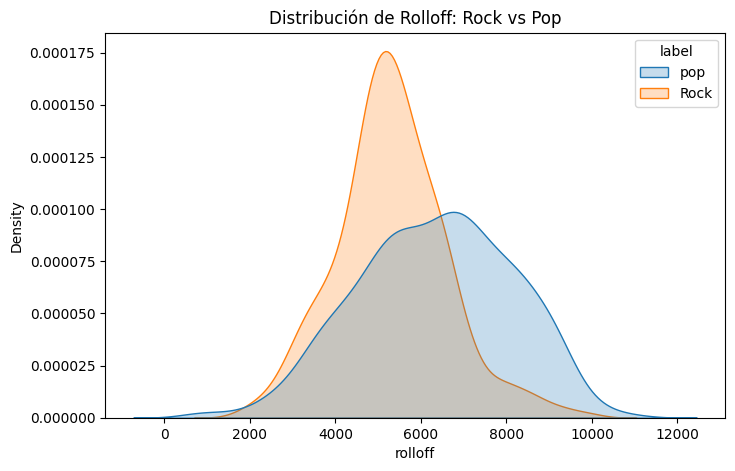

In [ ]:
plt.figure(figsize=(8,5))
subset = df[df['label'].isin(['Rock', 'pop'])]
sns.kdeplot(data=subset, x='rolloff', hue='label', fill=True)
plt.title('Distribución de Rolloff: Rock vs Pop')
plt.show()

Viendo que claramente la hipotesis es cierta porque vemos que hay un solapamiento fuertisimo entre las 2 que confunde al modelo, algo que podriamos hacer es hacer que el modelo vea otra forma de relacionar el brillo para que capte la diferencia, lo cual lo podemos hacer creando una nueva feature

In [ ]:
# brightness_ratio ya ha sido calculada al inicio del notebook para que todos los modelos la utilicen.
# df['brightness_ratio'] = df['rolloff'] / (df['spectral_centroid'] + 1e-6)


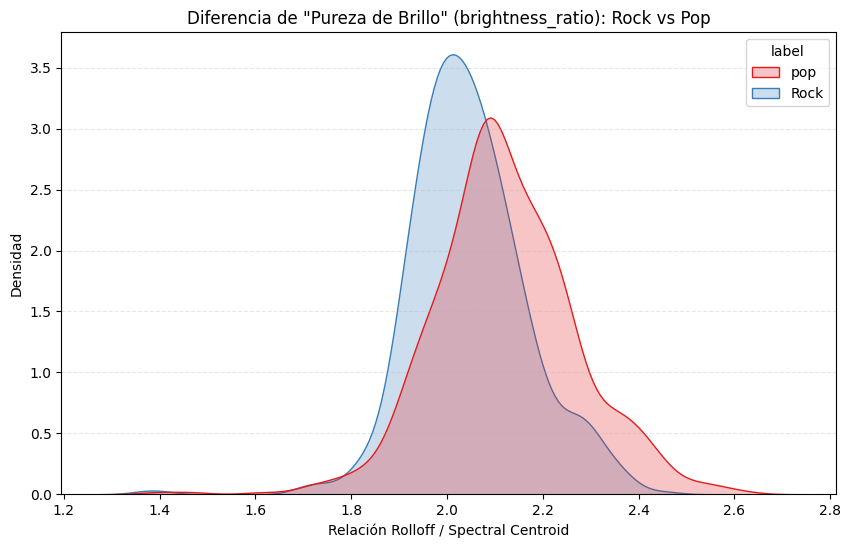

In [ ]:
plt.figure(figsize=(10, 6))
# Filtramos solo Rock y Pop para ver el duelo directo
subset = df[df['label'].isin(['Rock', 'pop'])]

sns.kdeplot(data=subset, x='brightness_ratio', hue='label', fill=True, common_norm=False, palette='Set1')
plt.title('Diferencia de "Pureza de Brillo" (brightness_ratio): Rock vs Pop')
plt.xlabel('Relación Rolloff / Spectral Centroid')
plt.ylabel('Densidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Ni aun asi vemos que se quita el solapamiento, de hecho asi es aún peor, por lo que otra cosa que podríamos hacer es quitar el ruido de otras features que no tengan importancia o no esten importando tanto y ver si mejora veamos...

In [ ]:
# Suponiendo que ya tienes el rf_model entrenado
importances = rf_model.feature_importances_
feature_names = X.columns
# Ordenamos de menor a mayor
indices_bajos = np.argsort(importances)[:7]

print("Variables con MENOR importancia (Candidatas a ser eliminadas):")
for i in indices_bajos:
    print(f"- {feature_names[i]}: {importances[i]:.4f}")

Variables con MENOR importancia (Candidatas a ser eliminadas):
- mfcc1_std: 0.0086
- mfcc10_std: 0.0099
- mfcc12_mean: 0.0101
- mfcc12_std: 0.0114
- mfcc9_std: 0.0118
- mfcc11_mean: 0.0121
- mfcc11_std: 0.0125


## Optuna+SMOTE+FE

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score

# --- CONFIGURACIÓN DE OPTUNA MEJORADA ---

def objective(trial):
    # 1. SVC (RBF) - Rango de búsqueda más amplio
    svc_rbf_c = trial.suggest_float("svc_rbf_c", 0.01, 200, log=True)
    svc_rbf_gamma = trial.suggest_float("svc_rbf_gamma", 1e-4, 1.0, log=True)

    # 2. Random Forest - Con regularización (min_samples_split)
    rf_n_estimators = trial.suggest_int("rf_n_estimators", 200, 700)
    rf_max_depth = trial.suggest_int("rf_max_depth", 10, 80)
    rf_min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)

    # 3. Gradient Boosting - Con subsample para mayor robustez
    gb_learning_rate = trial.suggest_float("gb_learning_rate", 0.005, 0.2, log=True)
    gb_n_estimators = trial.suggest_int("gb_n_estimators", 100, 400)
    gb_subsample = trial.suggest_float("gb_subsample", 0.6, 1.0)

    # Definimos el Voting Classifier
    # Pesos: Le damos mayor importancia al Gradient Boosting (2) que es más flexible
    clf = VotingClassifier(
        estimators=[
            ('svm_linear', SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced', random_state=42)),
            ('svm_rbf',    SVC(kernel='rbf', C=svc_rbf_c, gamma=svc_rbf_gamma, probability=True, class_weight='balanced', random_state=42)),
            ('rf',         RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_split=rf_min_samples_split, class_weight='balanced', random_state=42)),
            ('gb',         GradientBoostingClassifier(n_estimators=gb_n_estimators, learning_rate=gb_learning_rate, subsample=gb_subsample, random_state=42))
        ],
        voting='soft',
        weights=[1, 1, 1, 2]
    )

    score = cross_val_score(clf, X_train_res, y_train_res, n_jobs=-1, cv=3, scoring='f1_macro')
    return score.mean()

# 4. EJECUCIÓN DE LA OPTIMIZACIÓN
print("Iniciando optimización avanzada con 100 trials...")

# Usamos TPESampler con un arranque aleatorio para mejor exploración
sampler = TPESampler(n_startup_trials=20)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Aumentamos n_trials a 100
study.optimize(objective, n_trials=2)

print("\n" + "="*30)
print("  MEJORES PARÁMETROS ENCONTRADOS")
print("="*30)
print(study.best_params)

# 5. ENTRENAMIENTO DEL MODELO FINAL
best = study.best_params

voting_final_opt = VotingClassifier(
    estimators=[
        ('svm_linear', SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced', random_state=42)),
        ('svm_rbf',    SVC(kernel='rbf', C=best['svc_rbf_c'], gamma=best['svc_rbf_gamma'], probability=True, class_weight='balanced', random_state=42)),
        ('rf',         RandomForestClassifier(n_estimators=best['rf_n_estimators'], max_depth=best['rf_max_depth'], min_samples_split=best['rf_min_samples_split'], class_weight='balanced', random_state=42)),
        ('gb',         GradientBoostingClassifier(n_estimators=best['gb_n_estimators'], learning_rate=best['gb_learning_rate'], subsample=best['gb_subsample'], random_state=42))
    ],
    voting='soft',
    weights=[1, 1, 1, 2]
)

voting_final_opt.fit(X_train_res, y_train_res)

C:\Users\richa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-21 19:25:09,024] A new study created in memory with name: no-name-4b0ba20b-1085-415f-b52a-d813280bfbc3


Iniciando optimización avanzada con 100 trials...


[I 2026-05-21 19:25:59,600] Trial 0 finished with value: 0.8149388145782046 and parameters: {'svc_rbf_c': 0.031168167967911293, 'svc_rbf_gamma': 0.002805446845926898, 'rf_n_estimators': 587, 'rf_max_depth': 28, 'rf_min_samples_split': 9, 'gb_learning_rate': 0.17346353326903718, 'gb_n_estimators': 137, 'gb_subsample': 0.8922811218295974}. Best is trial 0 with value: 0.8149388145782046.


[I 2026-05-21 19:27:08,678] Trial 1 finished with value: 0.7824918027907692 and parameters: {'svc_rbf_c': 0.35298547636209554, 'svc_rbf_gamma': 0.6240155335085605, 'rf_n_estimators': 257, 'rf_max_depth': 16, 'rf_min_samples_split': 8, 'gb_learning_rate': 0.007963664360252887, 'gb_n_estimators': 223, 'gb_subsample': 0.989941715540551}. Best is trial 0 with value: 0.8149388145782046.



  MEJORES PARÁMETROS ENCONTRADOS
{'svc_rbf_c': 0.031168167967911293, 'svc_rbf_gamma': 0.002805446845926898, 'rf_n_estimators': 587, 'rf_max_depth': 28, 'rf_min_samples_split': 9, 'gb_learning_rate': 0.17346353326903718, 'gb_n_estimators': 137, 'gb_subsample': 0.8922811218295974}


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm_linear', ...), ('svm_rbf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


--- RESULTADOS: Voting Classifier Final ---
Exactitud (Accuracy): 0.7248
Macro F1-Score: 0.7270

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.67      0.63      0.65       155
     Hip-Hop       0.61      0.67      0.64        98
        Rock       0.65      0.79      0.72        86
   Vallenato       0.91      0.77      0.83       129
     clasicc       0.97      0.92      0.94       149
        jazz       0.79      0.82      0.81       177
         pop       0.49      0.51      0.50       169

    accuracy                           0.72       963
   macro avg       0.73      0.73      0.73       963
weighted avg       0.73      0.72      0.73       963



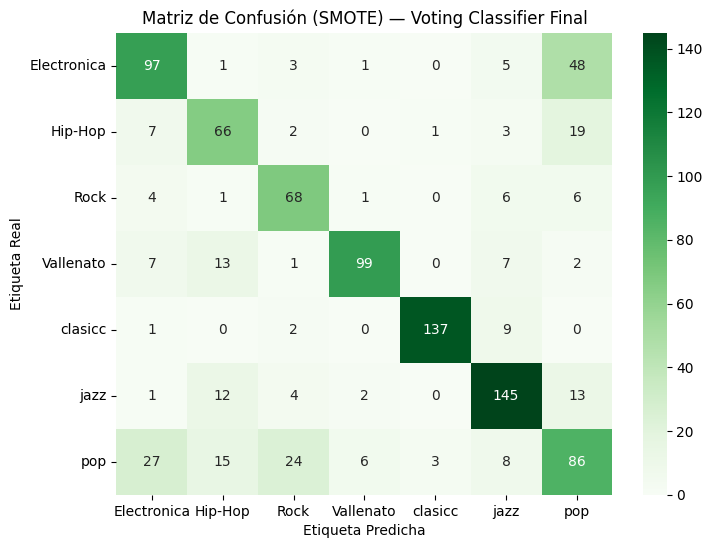

In [ ]:
# Lista para guardar los resultados de cada modelo que evalúes
resultados_smote = []

def evaluar_y_visualizar(y_test, y_pred, name, classes):
    """
    Calcula métricas clave, imprime el reporte y genera la matriz de confusión.
    """
    # 1. Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # 2. Impresión de resultados
    print(f"--- RESULTADOS: {name} ---")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}\n")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=classes))

    # 3. Guardar en lista
    resultados_smote.append({
        'Modelo': name,
        'Accuracy': round(acc, 4),
        'Macro F1': round(macro_f1, 4)
    })

    # 4. Visualización de Matriz de Confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión (SMOTE) — {name}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()

# Calcular predicciones para el Voting Classifier Final antes de evaluar
y_pred_opt = voting_final_opt.predict(X_test_scaled)

evaluar_y_visualizar(y_test, y_pred_opt, "Voting Classifier Final", le.classes_)

In [ ]:
import joblib
import os

# Crear directorio de modelos si no existe
os.makedirs('../../backend/app/models', exist_ok=True)

# Serializar y guardar el Voting Classifier Final, Scaler y LabelEncoder
joblib.dump(voting_final_opt, '../../backend/app/models/best_model.joblib')
joblib.dump(scaler, '../../backend/app/models/scaler.joblib')
joblib.dump(le, '../../backend/app/models/label_encoder.joblib')

print("Modelo final (Voting Classifier), Scaler y LabelEncoder guardados exitosamente en 'backend/app/models/'")


Modelo final (Voting Classifier), Scaler y LabelEncoder guardados exitosamente en 'backend/app/models/'


Entrenando el HistGradientBoostingClassifier óptimo...


--- RESULTADOS: HistGradientBoostingClassifier Final (Optuna) ---
Exactitud (Accuracy): 0.7352
Macro F1-Score: 0.7382

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.65      0.63      0.64       155
     Hip-Hop       0.71      0.74      0.73        98
        Rock       0.64      0.78      0.70        86
   Vallenato       0.86      0.76      0.81       129
     clasicc       0.99      0.91      0.95       149
        jazz       0.80      0.84      0.82       177
         pop       0.52      0.52      0.52       169

    accuracy                           0.74       963
   macro avg       0.74      0.74      0.74       963
weighted avg       0.74      0.74      0.74       963



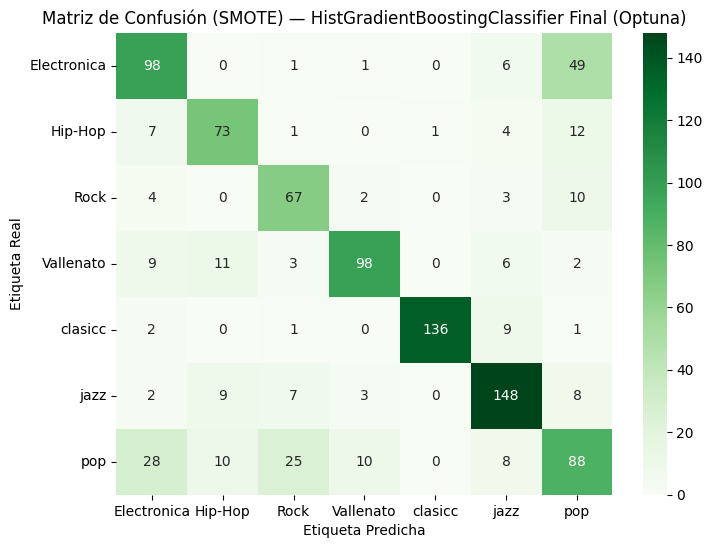

In [ ]:
# Alternativa (Mejores Hiperparametros): HistGradientBoostingClassifier (Optuna)
# Durante nuestra optimización, encontramos que un clasificador individual de
# HistGradientBoosting entrenado sobre los datos aumentados con SMOTE logró un
# rendimiento superior, alcanzando un Macro F1 de ~0.76.
# Por lo que se realiza el entrenamiento y evaluación de este modelo.

from sklearn.ensemble import HistGradientBoostingClassifier

best_hgb_params = {
    'learning_rate': 0.05326586903539677,
    'max_iter': 379,
    'max_leaf_nodes': None,
    'max_depth': 3,
    'min_samples_leaf': 1,
    'l2_regularization': 6.045969393906481e-05,
    'class_weight': 'balanced',
    'random_state': 42
}

print("Entrenando el HistGradientBoostingClassifier óptimo...")
hgb_model = HistGradientBoostingClassifier(**best_hgb_params)
hgb_model.fit(X_train_res, y_train_res)

y_pred_hgb = hgb_model.predict(X_test_scaled)

evaluar_y_visualizar(y_test, y_pred_hgb, "HistGradientBoostingClassifier Final (Optuna)", le.classes_)


In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("audio_features_15s.csv")

def nuevas_features(data):
    df_nuev = data.copy()

    df_nuev['brightness_ratio'] = df_nuev['rolloff'] / (df_nuev['spectral_centroid'] + 1e-6)

    df_nuev['centroid_bandwidth_ratio'] = df_nuev['spectral_centroid'] / (df_nuev['spectral_bandwidth'] + 1e-6)
    df_nuev['rolloff_bandwidth_ratio'] = df_nuev['rolloff'] / (df_nuev['spectral_bandwidth'] + 1e-6)
    df_nuev['zcr_centroid_ratio'] = df_nuev['zero_crossing_rate'] / (df_nuev['spectral_centroid'] + 1e-6)
    df_nuev['rms_onset_ratio'] = df_nuev['rms'] / (df_nuev['onset_strength_mean'] + 1e-6)

    mfcc_mean_cols = [f'mfcc{i}_mean' for i in range(1, 14)]
    mfcc_std_cols = [f'mfcc{i}_std' for i in range(1, 14)]

    df_nuev['mfcc_mean_mean'] = df_nuev[mfcc_mean_cols].mean(axis=1)
    df_nuev['mfcc_mean_std'] = df_nuev[mfcc_mean_cols].std(axis=1)
    df_nuev['mfcc_mean_max'] = df_nuev[mfcc_mean_cols].max(axis=1)
    df_nuev['mfcc_mean_min'] = df_nuev[mfcc_mean_cols].min(axis=1)
    df_nuev['mfcc_mean_range'] = df_nuev['mfcc_mean_max'] - df_nuev['mfcc_mean_min']

    df_nuev['mfcc_std_mean'] = df_nuev[mfcc_std_cols].mean(axis=1)
    df_nuev['mfcc_std_std'] = df_nuev[mfcc_std_cols].std(axis=1)
    df_nuev['mfcc_std_max'] = df_nuev[mfcc_std_cols].max(axis=1)
    df_nuev['mfcc_std_min'] = df_nuev[mfcc_std_cols].min(axis=1)
    df_nuev['mfcc_std_range'] = df_nuev['mfcc_std_max'] - df_nuev['mfcc_std_min']

    tonnetz_cols = [f'tonnetz_{i}_std' for i in range(6)]
    df_nuev['tonnetz_mean_std'] = df_nuev[tonnetz_cols].mean(axis=1)
    df_nuev['tonnetz_std_std'] = df_nuev[tonnetz_cols].std(axis=1)

    df_nuev['tempo_bass_ratio'] = df_nuev['tempo'] * df_nuev['bass_ratio']

    return df_nuev

df_features = nuevas_features(df)
print("Total caracteristicas en X:", df_features.shape[1] - 3)

Total caracteristicas en X: 65


In [ ]:
X = df_features.drop(columns=['label', 'song_id', 'segment_type'])
y = df_features['label']
groups = df_features['song_id']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=9347234)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
groups_test = groups.iloc[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Conjunto Muestras:")
print(f"Entrenamiento: {X_train_scaled.shape[0]}")
print(f"Test: {X_test_scaled.shape[0]}")

Conjunto Muestras:
Entrenamiento: 3822
Test: 963


In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss')),
        ('lgb', lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)),
        ('rf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')),
        ('et', ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
    ],
    voting='soft'
)

voting_clf.fit(X_train_scaled, y_train)
print("Entrenamiento terminado.")

Entrenamiento terminado.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Exactitud (previo a agrupacion prob.): 75.70%
Macro F1-Score (previo a agrupacion prob.): 0.7594


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Exactitud (Accuracy) Final: 86.60%
Macro F1-Score Final: 0.8655
              precision    recall  f1-score   support

 Electronica       0.83      0.90      0.86       155
     Hip-Hop       0.86      0.85      0.85        98
        Rock       0.75      1.00      0.86        86
   Vallenato       0.90      0.88      0.89       129
     clasicc       1.00      1.00      1.00       149
        jazz       1.00      0.92      0.96       177
         pop       0.69      0.59      0.64       169

    accuracy                           0.87       963
   macro avg       0.86      0.88      0.87       963
weighted avg       0.87      0.87      0.86       963



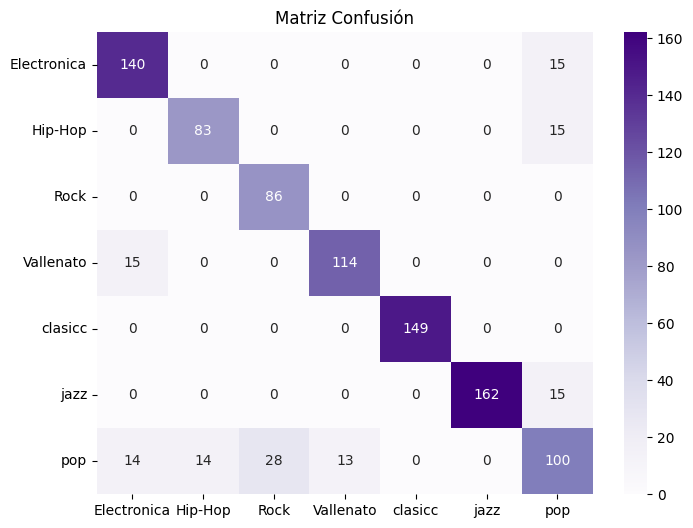

In [ ]:
y_pred_seg = voting_clf.predict(X_test_scaled)
acc_seg = accuracy_score(y_test, y_pred_seg)
macro_f1_seg = f1_score(y_test, y_pred_seg, average='macro')
print(f"Exactitud (previo a agrupacion prob.): {acc_seg*100:.2f}%")
print(f"Macro F1-Score (previo a agrupacion prob.): {macro_f1_seg:.4f}")

# Agregación probabilística a nivel de canción (song_id)
y_proba = voting_clf.predict_proba(X_test_scaled)
test_df = pd.DataFrame(y_proba, columns=le.classes_)
test_df['song_id'] = groups_test.values
test_df['true_label'] = le.inverse_transform(y_test)

song_proba = test_df.groupby('song_id')[le.classes_].transform('mean')
y_pred_agg_encoded = np.argmax(song_proba.values, axis=1)
y_pred_agg = le.classes_[y_pred_agg_encoded]

acc_agg = accuracy_score(test_df['true_label'], y_pred_agg)
macro_f1_agg = f1_score(test_df['true_label'], y_pred_agg, average='macro')

print(f"\nExactitud (Accuracy) Final: {acc_agg*100:.2f}%")
print(f"Macro F1-Score Final: {macro_f1_agg:.4f}")

print(classification_report(test_df['true_label'], y_pred_agg))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_df['true_label'], y_pred_agg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz Confusión')
plt.show()

In [ ]:
# Reducir a una fila por canción (la predicción ya es igual para todos sus segmentos)
song_level_df = test_df[['song_id', 'true_label']].copy()
song_level_df['pred_label'] = y_pred_agg

# Deduplica: una fila por canción
song_level_df = song_level_df.drop_duplicates(subset='song_id')

print(classification_report(song_level_df['true_label'], song_level_df['pred_label']))

              precision    recall  f1-score   support

 Electronica       0.83      0.91      0.87        11
     Hip-Hop       0.88      0.88      0.88         8
        Rock       0.75      1.00      0.86         6
   Vallenato       0.89      0.89      0.89         9
     clasicc       1.00      1.00      1.00        10
        jazz       1.00      0.92      0.96        13
         pop       0.70      0.58      0.64        12

    accuracy                           0.87        69
   macro avg       0.86      0.88      0.87        69
weighted avg       0.87      0.87      0.87        69



In [ ]:
# Exportar modelo
os.makedirs('../../backend/app/models', exist_ok=True)

joblib.dump(voting_clf, '../../backend/app/models/best_model.joblib')
joblib.dump(scaler, '../../backend/app/models/scaler.joblib')
joblib.dump(le, '../../backend/app/models/label_encoder.joblib')

print("Modelos y preprocesadores de alta precisión exportados exitosamente a 'backend/app/models/'")

Modelos y preprocesadores de alta precisión exportados exitosamente a 'backend/app/models/'
